In [1]:
import sys
sys.path.append("..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

from src.tokenizer.vectorizer import VocabularyVectorizer
from src.tokenizer.corpus import Corpus


In [3]:
df = pd.read_csv(
    "../data/text_corpus.csv",
    encoding="utf-8"
)
texts = df["comment"].tolist()
corpus = Corpus(texts)


vectorizer = VocabularyVectorizer(
    "../data/vocabulary.csv"
)


X = vectorizer.transform(
    corpus
)

print(X.shape)

(10000, 506)


In [4]:
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_svd = svd.fit_transform(X)

X_svd.shape

(10000, 50)

In [5]:
svd.explained_variance_ratio_.sum()

np.float64(0.9157477118620926)

In [6]:
X_norm = normalize(X_svd)
# и cosine становится обычным скалярным произведением.

In [7]:
kmeans = KMeans(
    n_clusters=15,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_norm)

In [8]:
pd.Series(labels).value_counts().sort_index()

0     1085
1      671
2      461
3     1162
4      356
5      658
6      430
7      445
8      289
9      976
10    1071
11     834
12     601
13     209
14     752
Name: count, dtype: int64

In [9]:
df["cluster"] = labels

df[df.cluster == 0].comment.to_list()[:30]

['По услуге Интернет есть проблемы. Причина - проблема абонентского оборудования.',
 'OTT отсутствует. Причина - проблема абонентского оборудования.',
 'На FTTx зарегистрировано: DHCP отсутствует. Причина - проблема абонентского оборудования.',
 'По услуге ВИП есть проблемы. Причина - проблема абонентского оборудования.',
 'цифровое ТВ (xPON) плохое качество. Причина - проблема абонентского оборудования.',
 'OTT отсутствует. Причина - проблема абонентского оборудования.',
 'OTT. Wi-Fi. проблема абонентского оборудования.',
 'падает сессия. Причина - проблема абонентского оборудования.',
 'На Wi—Fi зарегистрировано: нет DHCP. Причина — проблема абонентского оборудования.',
 'Интернет есть проблемы. Причина - проблема абонентского оборудования.',
 'ВИП. падает сессия. Причина - проблема абонентского оборудования.',
 'IoT отсутствует. Причина - проблема абонентского оборудования.',
 'По услуге ШПД отсутствует. Причина - проблема абонентского оборудования.',
 'Интернет. нет DHCP. Причина —

In [10]:
df[df.cluster == 1].comment.to_list()[:30]

['CTV. не работают приложения. Причина - авария оборудования.',
 'На GPON зарегистрировано: не работают приложения. Причина - неисправность оборудования провайдера.',
 'ВИП. PON. не работают приложения.',
 'На GPON зарегистрировано: не работают приложения. Причина - проблема абонентского оборудования.',
 'не работают приложения. Причина - неисправность оборудования абонента.',
 'CTV. не работают приложения. Причина - неисправность оборудования абонента.',
 'не работают приложения. Причина - проблема абонентского оборудования.',
 'На WiFi зарегистрировано: не работают приложения. Причина - неисправность оборудования абонента.',
 'На ШПД зарегистрировано: не работают приложения. Причина - воздействие третьей стороны.',
 'На PON зарегистрировано: не работают приложения. Причина - неисправность оборудования провайдера.',
 'OTT. Wi-Fi. не работают приложения.',
 'Интернет. WiFi. не работают приложения.',
 'На GPON зарегистрировано: не работают приложения. Причина - неисправность оборудовани

In [11]:
sim = cosine_similarity(
    X_norm[0:1],
    X_norm
)[0]


top = sim.argsort()[-10:][::-1]


df.iloc[top].comment.to_list()

['доступ в Интернет (FTTx) отсутствует. Причина - проблема абонентского оборудования.',
 'доступ в Интернет (FTTx) отсутствует. Причина - проблема абонентского оборудования.',
 'доступ в Интернет (FTTx) отсутствует. Причина - проблема абонентского оборудования.',
 'доступ в Интернет (FTTx) отсутствует. Причина - проблема абонентского оборудования. выполняется локализация',
 'доступ в Интернет. FTTx. проблема абонентского оборудования.',
 'доступ в Интернет. FTTx. проблема абонентского оборудования.',
 'доступ в Интернет. FTTx. проблема абонентского оборудования.',
 'доступ в Интернет (Wi-Fi) отсутствует. Причина - проблема абонентского оборудования.',
 'доступ в Интернет (PON) отсутствует. Причина - проблема абонентского оборудования.',
 'доступ в Интернет (WiFi) отсутствует. Причина - проблема абонентского оборудования.']

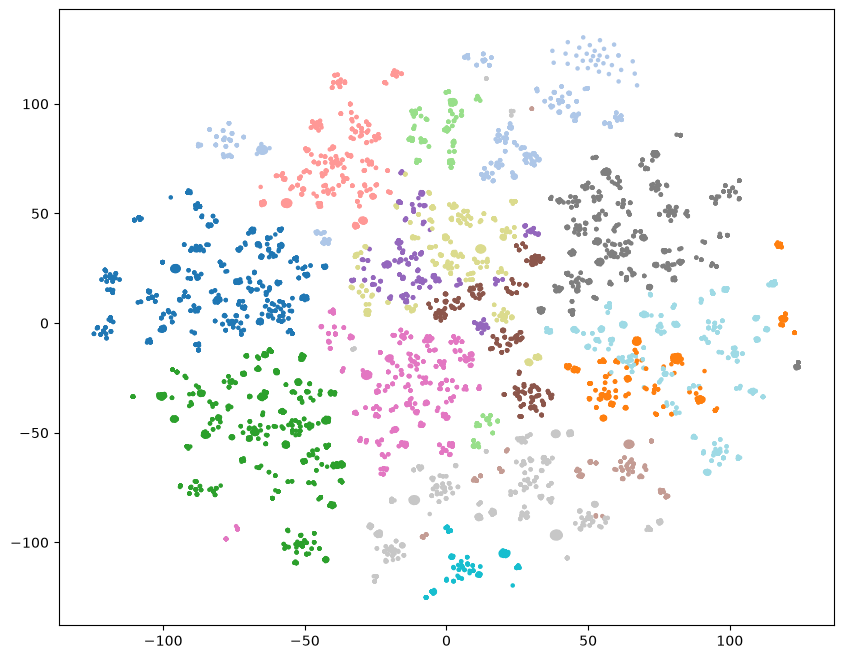

In [12]:
X_2d = TSNE(
    n_components=2,
    random_state=42
).fit_transform(
    X_svd
)

plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,
    s=5,
    cmap="tab20"
)

plt.show()

# При переносе в закрытый контур я бы сохранил тот же pipeline без изменений:

реальный CRM корпус
        ↓
Corpus
        ↓
Statistics
        ↓
CandidateExtractor
        ↓
VocabularyBuilder
        ↓
vocabulary.csv
        ↓
VocabularyVectorizer
        ↓
BoW matrix
        ↓
SVD
        ↓
clustering

# Но есть несколько практических моментов, которые стоит сразу учитывать:

## На реальном корпусе первым делом смотреть не кластеры, а статистику словаря

Перед SVD я бы посмотрел: len(vocabulary) и df_vocab["freq"].describe()

### В реальном CRM почти наверняка появятся:
* внутренние сокращения;
* названия систем;
* фамилии/инициалы;
* номера заявок;
* шаблонные фразы операторов;
* технические статусы.

И вот здесь станет видно, насколько хорошо работает текущий Normalizer.

## Скорее всего появится необходимость в "domain stop words"

Не обычные языковые стоп-слова типа: и, в, на, по

а CRM-специфичные: зарегистрировано, обращение, клиент, абонент, выполнено, передано, создано

# Синтетика дала хороший "санитарный" тест

Самое ценное, что вы теперь знаете: если на реальном корпусе кластеры окажутся плохими, проблема будет не в общей архитектуре.

## Будет понятно, где искать:
* качество исходных комментариев;
* нормализация;
* шум терминов;
* недостаток корпуса;
* слишком высокая/низкая детализация словаря.

И ещё один практический момент: если в закрытом контуре запрещены внешние модели и API, ваш подход очень хорошо подходит под такие ограничения. 

## Вся цепочка полностью локальная и объяснимая:
* статистика;
* словарь;
* векторизация;
* SVD;
* кластеризация;

Для технической поддержки это часто даже преимущество: можно показать, какой именно термин привёл тикет в кластер.